In [1]:
# Importation des bibliothèques nécessaires
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [2]:
# Chargement des données MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
# Vérification des dimensions des données
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


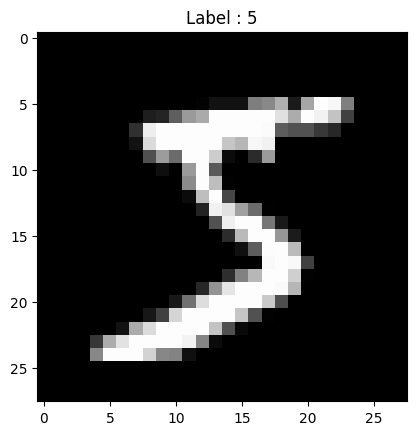

In [4]:
# Visualisation d'un exemple d'image et de son label
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label : {y_train[0]}")
plt.show()

# PARTIE A : Réseau neuronal classique (ANN)

In [6]:
# Aplatissement des images pour l'entrée du réseau de neurones
X_train_ann = X_train.reshape(60000, 784)
X_test_ann = X_test.reshape(10000, 784)

In [7]:
# Normalisation des données
X_train_ann = X_train_ann.astype("float32") / 255
X_test_ann = X_test_ann.astype("float32") / 255

In [8]:
# Encodage one-hot des labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [10]:
# Définition du modèle ANN
model_ann = tf.keras.Sequential([
    
    # Couches denses avec activation ReLU et softmax
    tf.keras.layers.Dense(
        128,
        activation='relu',
        input_shape=(784,)
    ),

    tf.keras.layers.Dense(
        64,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )
])

c:\Users\HP 840 G3\DAILYCHALLENGES\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Compilation du modèle avec l'optimiseur Adam, la fonction de perte categorical_crossentropy et la métrique de justesse
model_ann.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Entraînement du modèle ANN sur les données d'entraînement avec validation
history_ann = model_ann.fit(
    X_train_ann,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9225 - loss: 0.2659 - val_accuracy: 0.9556 - val_loss: 0.1440
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9664 - loss: 0.1126 - val_accuracy: 0.9691 - val_loss: 0.1048
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9766 - loss: 0.0756 - val_accuracy: 0.9711 - val_loss: 0.0935
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9816 - loss: 0.0576 - val_accuracy: 0.9712 - val_loss: 0.0974
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9855 - loss: 0.0451 - val_accuracy: 0.9751 - val_loss: 0.0875
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9889 - loss: 0.0344 - val_accuracy: 0.9758 - val_loss: 0.0875
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9909 - loss: 0.0281 - val_accuracy: 0.9762 - val_loss: 0.0949
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9914 - loss: 0.02

In [ ]:
# Évaluation du modèle ANN sur les données de test
loss_ann, acc_ann = model_ann.evaluate(
    X_test_ann,
    y_test_cat
)

print(acc_ann)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9706 - loss: 0.1207
0.9706000089645386


# PARTIE B : CNN

In [ ]:
# Remodeler des données pour le modèle CNN
X_train_cnn = X_train.reshape(
    60000,
    28,
    28,
    1
)

X_test_cnn = X_test.reshape(
    10000,
    28,
    28,
    1
)

In [18]:
# Normalisation des données
X_train_cnn = X_train_cnn.astype("float32") / 255
X_test_cnn = X_test_cnn.astype("float32") / 255

In [ ]:
# Définition du modèle CNN
model_cnn = tf.keras.Sequential([
    # Couches de convolution et de pooling pour extraire les caractéristiques des images
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),
    # Couche de pooling pour réduire la dimensionnalité
    
    tf.keras.layers.MaxPooling2D((2,2)),
    # Deuxième couche de convolution pour extraire des caractéristiques plus complexes
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    
    # Deuxième couche de pooling pour réduire davantage la dimensionnalité
    tf.keras.layers.MaxPooling2D((2,2)),

    # Couche de flatten pour aplatir les caractéristiques extraites avant les couches denses
    tf.keras.layers.Flatten(),

    # Couches denses pour la decision finale avec activation ReLU et softmax
    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    # Prédiction finale avec activation softmax pour la classification multi-classes
    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )

])

c:\Users\HP 840 G3\DAILYCHALLENGES\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
# Compilation du modèle CNN avec l'optimiseur Adam, la fonction de perte categorical_crossentropy et la métrique de justesse
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
# Entraînement du modèle CNN sur les données d'entraînement avec validation
history_cnn = model_cnn.fit(
    X_train_cnn,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.9529 - loss: 0.1524 - val_accuracy: 0.9829 - val_loss: 0.0571
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.9844 - loss: 0.0476 - val_accuracy: 0.9859 - val_loss: 0.0459
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9893 - loss: 0.0327 - val_accuracy: 0.9875 - val_loss: 0.0403
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9926 - loss: 0.0226 - val_accuracy: 0.9893 - val_loss: 0.0377
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9944 - loss: 0.0172 - val_accuracy: 0.9908 - val_loss: 0.0337
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 18ms/step - accuracy: 0.9961 - loss: 0.0125 - val_accuracy: 0.9894 - val_loss: 0.0395
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.9965 - loss: 0.0104 - val_accuracy: 0.9887 - val_loss: 0.0480
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.9972 -

In [25]:
# Évaluation du modèle CNN sur les données de test
loss_cnn, acc_cnn = model_cnn.evaluate(
    X_test_cnn,
    y_test_cat
)

print(acc_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9893 - loss: 0.0445
0.989300012588501


# Comparaison finale

# Typiquement :

# Modèle           |             	Accuracy
ANN	               |                97%
CNN	               |                99%